In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**CNN**

In [ ]:
#load data

data_dir = '/content/drive/MyDrive/dl4m/dl4m_final/MC_vocals'
output_dir = "/content/drive/MyDrive/dl4m/dl4m_final/MC_features"
os.makedirs(output_dir, exist_ok=True)

label_map = {"Mandarin": 0, "Cantonese": 1}

X, y = [], []

# extract log-mel features
def extract_log_mel(y, sr, n_mels=64):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel


# data augmentation
def augment_audio(y, sr):
    aug_audio = []

    # speed perturbation
    speed = np.random.uniform(0.9, 1.1)
    y_speed = librosa.resample(y, orig_sr=sr, target_sr=int(sr * speed))
    aug_audio.append(y_speed)

    # pitch shifting
    pitch = np.random.uniform(-1, 1)
    y_pitch = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=pitch)
    aug_audio.append(y_pitch)

    # add noise
    noise = np.random.randn(len(y))
    y_noise = y + 0.003 * noise
    aug_audio.append(y_noise)

    # volume scaling
    gain = np.random.uniform(0.8, 1.2)
    y_gain = np.clip(y * gain, -1.0, 1.0)
    aug_audio.append(y_gain)

    return aug_audio


def extract_log_mel(y, sr, n_mels=64, target_len=188):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    if log_mel.shape[1] < target_len:
        pad_width = target_len - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mel = log_mel[:, :target_len]
    return log_mel


for lang in ["Mandarin", "Cantonese"]:
    input_path = os.path.join(data_dir, lang)
    label = label_map[lang]

    for fname in tqdm(os.listdir(input_path), desc=f"Processing {lang}"):

        path = os.path.join(input_path, fname)
        y_audio, sr = librosa.load(path, sr=16000, duration=3.0)

        log_mel = extract_log_mel(y_audio, sr)
        X.append(log_mel)
        y.append(label)

        for y_aug in augment_audio(y_audio, sr):
            log_mel_aug = extract_log_mel(y_aug, sr)
            X.append(log_mel_aug)
            y.append(label)

X = np.array(X)
y = np.array(y)
np.save(os.path.join(output_dir, "X.npy"), X)
np.save(os.path.join(output_dir, "y.npy"), y)
print("✅ features saved", X.shape, y.shape)

Processing Cantonese: 100%|██████████| 400/400 [00:52<00:00,  7.69it/s]


✅ features saved (4000, 64, 188) (4000,)


In [ ]:
X = np.load(os.path.join(output_dir, "X.npy"))
y = np.load(os.path.join(output_dir, "y.npy"))
X = np.expand_dims(X, axis=-1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

model = models.Sequential([
    layers.Input(shape=X.shape[1:]),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 68s 660ms/step - accuracy: 0.5041 - loss: 8.6555 - val_accuracy: 0.5100 - val_loss: 0.6929
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 546ms/step - accuracy: 0.5517 - loss: 0.6876 - val_accuracy: 0.5750 - val_loss: 0.6849
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 540ms/step - accuracy: 0.6394 - loss: 0.6376 - val_accuracy: 0.6438 - val_loss: 0.6171
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 81s 534ms/step - accuracy: 0.7101 - loss: 0.5470 - val_accuracy: 0.7225 - val_loss: 0.5633
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 590ms/step - accuracy: 0.7760 - loss: 0.4475 - val_accuracy: 0.7588 - val_loss: 0.4987
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 543ms/step - accuracy: 0.8335 - loss: 0.3677 - val_accuracy: 0.8313 - val_loss: 0.4022
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 536ms/step - accuracy: 0.8808 - loss: 0.2853 - val_accuracy: 0.8037 - val_loss: 0.3959
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 546ms/step - accuracy: 0.8894 - loss: 0

In [ ]:
# evaluate

loss, acc = model.evaluate(X_val, y_val)
print(f"✅ Accuracy: {acc:.2%}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.9226 - loss: 0.2299
✅ Accuracy: 92.87%


In [ ]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print(classification_report(y_val, y_pred, target_names=["Mandarin", "Cantonese"]))

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step
              precision    recall  f1-score   support

    Mandarin       0.95      0.91      0.93       400
   Cantonese       0.91      0.95      0.93       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



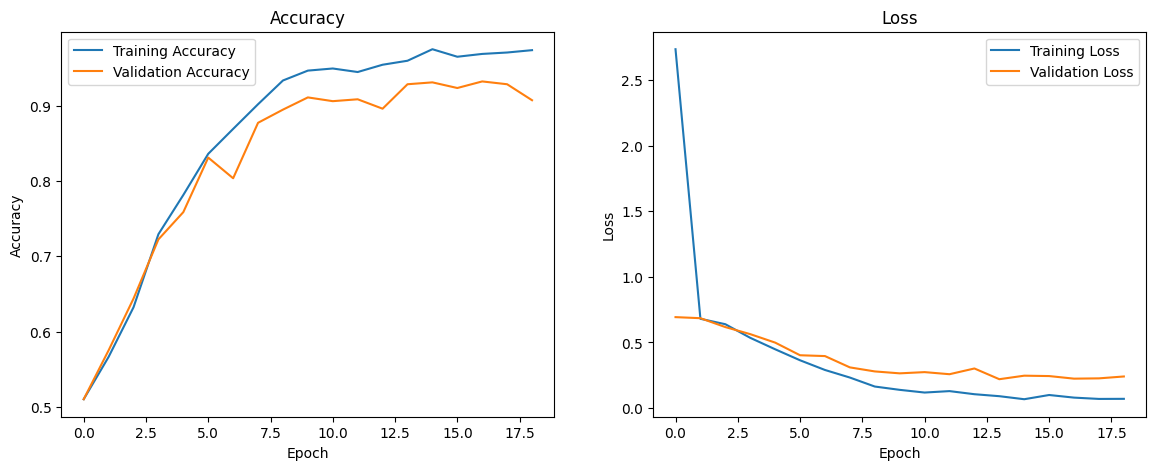

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()